# Attention Mechanism - AG News Topic Classification

This project applies an attention mechanism to multi-class news topic classification using the AG News dataset. A bidirectional LSTM first encodes the sequence, after which attention learns which hidden states contribute most strongly to the final document representation. The notebook evaluates classification performance and visualizes attention weights for selected news articles.

## 1. Import Required Libraries

Import the libraries required for dataset loading, text preprocessing, model development, visualization and evaluation.

In [1]:
import os
import logging

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

tf.get_logger().setLevel(logging.ERROR)
tfds.disable_progress_bar()

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Layer,
    TextVectorization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)
print("TensorFlow Datasets Version:", tfds.__version__)

TensorFlow Version: 2.21.0
TensorFlow Datasets Version: 4.9.10


## 2. Load the AG News Dataset

Load AG News from TensorFlow Datasets and create deterministic training, validation and test splits.

In [2]:
train_ds_raw, test_ds_raw = tfds.load(
    "ag_news_subset",
    split=["train", "test"],
    as_supervised=True,
    shuffle_files=False
)

train_items = list(tfds.as_numpy(train_ds_raw))
test_items = list(tfds.as_numpy(test_ds_raw))

train_texts = np.array(
    [text.decode("utf-8") for text, _ in train_items]
)

train_labels = np.array(
    [label for _, label in train_items],
    dtype=np.int32
)

test_texts = np.array(
    [text.decode("utf-8") for text, _ in test_items]
)

test_labels = np.array(
    [label for _, label in test_items],
    dtype=np.int32
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

Training Samples: 96000
Validation Samples: 24000
Test Samples: 7600


## 3. Explore the Dataset

Inspect class distribution and representative examples.

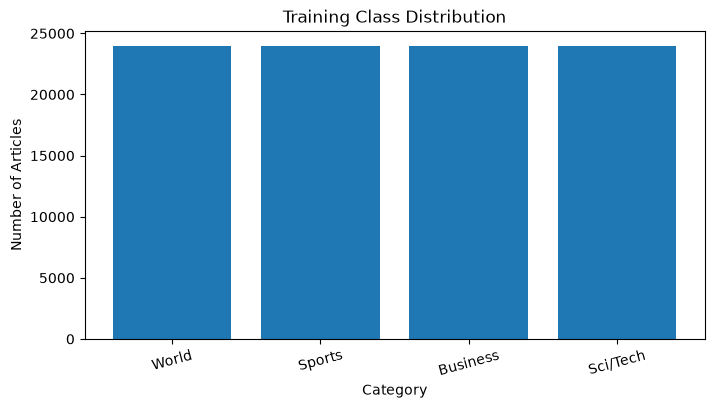

Category: World
Pakistani jets on Thursday pounded a suspected training facility for foreign militants in a tribal area near the border with Afghanistan, senior intelligence and military officials said.

Category: Sports
Ford confirmed on Monday that Red Bull had bought their Formula One team and that their engine manufacturer Cosworth had been sold to the owners of the Champ Car series.

Category: Business
Union leaders and advocates for the poor are uniting behind an effort to raise the state's \$6.75-an-hour minimum wage for the first time since 2001 and to tie future increases to the inflation rate, a move that would make Massachusetts only the fourth state in the nation to establish that link.

Category: Sci/Tech
University of California regents yesterday resoundingly rejected a proposal that sought to add a  quot;multiracial quot; category to UC #39;s admissions application.



In [3]:
classes, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in classes], counts)
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.title("Training Class Distribution")
plt.xticks(rotation=15)
plt.show()

for label in range(4):
    idx = np.where(train_labels == label)[0][0]
    print("=" * 90)
    print(f"Category: {class_names[label]}")
    print(train_texts[idx][:500])
    print()

## 4. Preprocess the Text

Convert raw articles into fixed-length integer sequences. The vocabulary is learned only from the training data.

In [4]:
max_tokens = 20000
sequence_length = 200

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"
)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_texts).batch(256)
)

vocabulary_size = len(vectorizer.get_vocabulary())

print("Vocabulary Size:", vocabulary_size)
print("Sequence Length:", sequence_length)
print("Sample Token Shape:", vectorizer(tf.constant([train_texts[0]])).shape)

Vocabulary Size: 20000
Sequence Length: 200
Sample Token Shape: (1, 200)


## 5. Create TensorFlow Input Pipelines

Build efficient mini-batch datasets for training and evaluation.

In [5]:
batch_size = 128

train_data = tf.data.Dataset.from_tensor_slices(
    (train_texts, train_labels)
).shuffle(
    buffer_size=len(train_texts),
    seed=42,
    reshuffle_each_iteration=True
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices(
    (val_texts, val_labels)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_data = tf.data.Dataset.from_tensor_slices(
    (test_texts, test_labels)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

## 6. Build the BiLSTM with Attention

Construct a bidirectional LSTM encoder followed by an additive attention layer that learns a weight for each sequence position.

In [6]:
class AdditiveAttention(Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)

        self.score_dense = Dense(
            units,
            activation="tanh"
        )
        self.weight_dense = Dense(1)

    def call(self, inputs):
        scores = self.score_dense(inputs)
        scores = self.weight_dense(scores)
        scores = tf.squeeze(scores, axis=-1)

        attention_weights = tf.nn.softmax(
            scores,
            axis=1
        )

        context_vector = tf.reduce_sum(
            inputs * tf.expand_dims(
                attention_weights,
                axis=-1
            ),
            axis=1
        )

        return context_vector, attention_weights


text_input = Input(
    shape=(),
    dtype=tf.string,
    name="text_input"
)

token_ids = vectorizer(text_input)

embedding = Embedding(
    input_dim=vocabulary_size,
    output_dim=128,
    mask_zero=False,
    name="embedding"
)(token_ids)

sequence_output = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    ),
    name="bilstm"
)(embedding)

attention_layer = AdditiveAttention(
    units=64,
    name="attention"
)

context_vector, attention_weights = attention_layer(
    sequence_output
)

x = Dense(
    64,
    activation="relu"
)(context_vector)

output = Dense(
    4,
    activation="softmax",
    name="classifier"
)(x)

attention_model = Model(
    inputs=text_input,
    outputs=output,
    name="BiLSTM_Attention_Classifier"
)

inference_model = Model(
    inputs=text_input,
    outputs=[
        output,
        attention_weights
    ],
    name="Attention_Inference_Model"
)

attention_model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

attention_model.summary()

Model: "BiLSTM_Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AdditiveAttention)   │ [(None, 128), (None,   │         8,321 │
│                                 │ 200)]                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,675,653 (10.21 MB)

 Trainable params: 2,675,653 (10.21 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

Train the classifier while monitoring validation loss. EarlyStopping restores the best-performing model weights.

In [7]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = attention_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    shuffle=False,
    callbacks=[early_stopping]
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

print("Best Epoch:", best_epoch)
print(
    f"Best Validation Loss: "
    f"{history.history['val_loss'][best_epoch - 1]:.4f}"
)
print(
    f"Best Validation Accuracy: "
    f"{history.history['val_accuracy'][best_epoch - 1]:.4f}"
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 272s 359ms/step - accuracy: 0.8498 - loss: 0.4110 - val_accuracy: 0.9061 - val_loss: 0.2791
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 322s 429ms/step - accuracy: 0.9301 - loss: 0.2066 - val_accuracy: 0.9075 - val_loss: 0.2772
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 337s 450ms/step - accuracy: 0.9478 - loss: 0.1510 - val_accuracy: 0.9031 - val_loss: 0.3029
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 322s 429ms/step - accuracy: 0.9616 - loss: 0.1101 - val_accuracy: 0.9031 - val_loss: 0.3359
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 351s 469ms/step - accuracy: 0.9728 - loss: 0.0784 - val_accuracy: 0.8974 - val_loss: 0.3954
Best Epoch: 2
Best Validation Loss: 0.2772
Best Validation Accuracy: 0.9075


## 8. Training Curves

Visualize training and validation accuracy and loss.

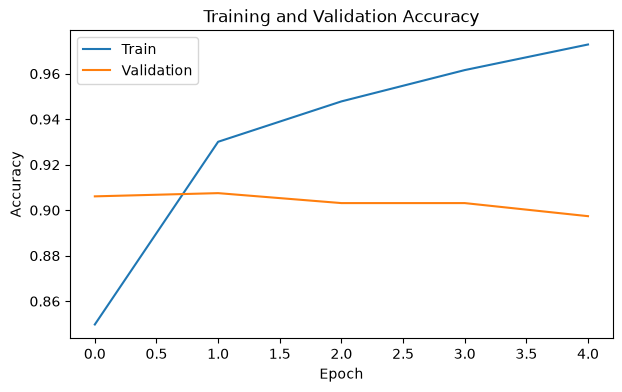

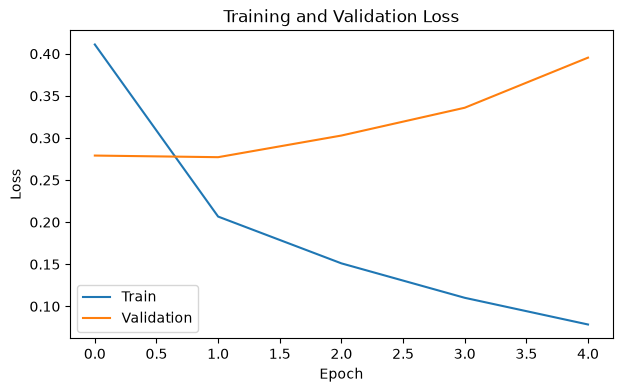

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## 9. Evaluate the Model

Evaluate the restored best model on the held-out test set.

In [9]:
test_loss, test_accuracy = attention_model.evaluate(test_data, verbose=0)
probabilities = attention_model.predict(test_data, verbose=0)
predictions = np.argmax(probabilities, axis=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2659
Test Accuracy: 0.9093


## 10. Classification Report

Measure precision, recall and F1-score for each news category.

In [10]:
print(classification_report(
    test_labels,
    predictions,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

       World     0.9422    0.8837    0.9120      1900
      Sports     0.9433    0.9816    0.9621      1900
    Business     0.8851    0.8679    0.8764      1900
    Sci/Tech     0.8686    0.9042    0.8860      1900

    accuracy                         0.9093      7600
   macro avg     0.9098    0.9093    0.9091      7600
weighted avg     0.9098    0.9093    0.9091      7600



## 11. Confusion Matrix

Visualize class-level prediction errors.

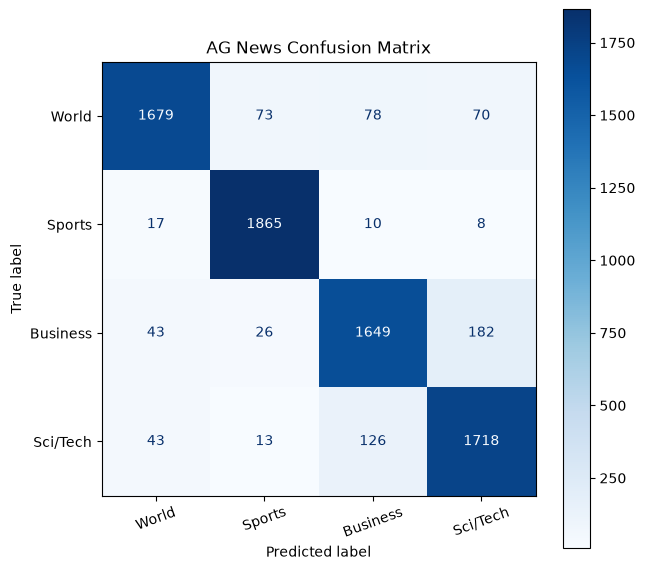

In [11]:
cm = confusion_matrix(test_labels, predictions)

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", xticks_rotation=20)

plt.title("AG News Confusion Matrix")
plt.show()

## 12. Visualize Attention Weights

Inspect the tokens receiving the highest attention weights for selected test articles.

True Label     : Sports
Predicted Label: Sports
Article:  CHARLOTTE, N.C. (Sports Network) - Carolina Panthers  running back Stephen Davis will miss the remainder of the  season after being placed on injured reserve Saturday.


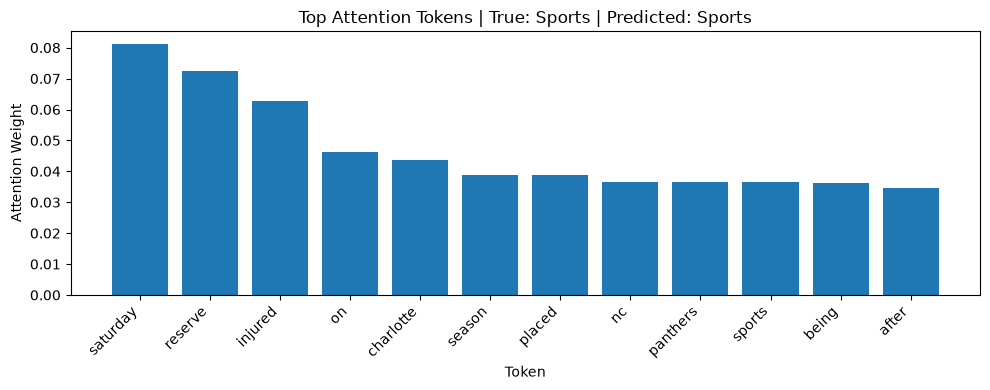

True Label     : World
Predicted Label: World
Article:  PRESENTACION, Philippines (Reuters) - Philippine communist  rebels freed Wednesday two soldiers they had held as "prisoners  of war" for more than five months, saying they wanted to  rebuild confidence in peace talks with the government.


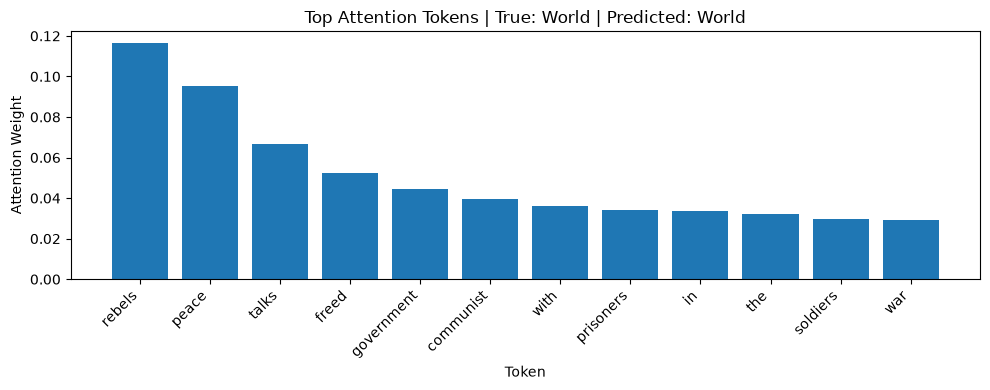

True Label     : Sci/Tech
Predicted Label: Sci/Tech
Article: SAN FRANCISCO, CA - November 30, 2004 -Ubisoft, one of the world #39;s largest video game publishers, today announced its plans to launch the next installment in the Tom Clancy #39;s Rainbow SixR franchise for the Sony PlayStationR2 computer entertainment system 


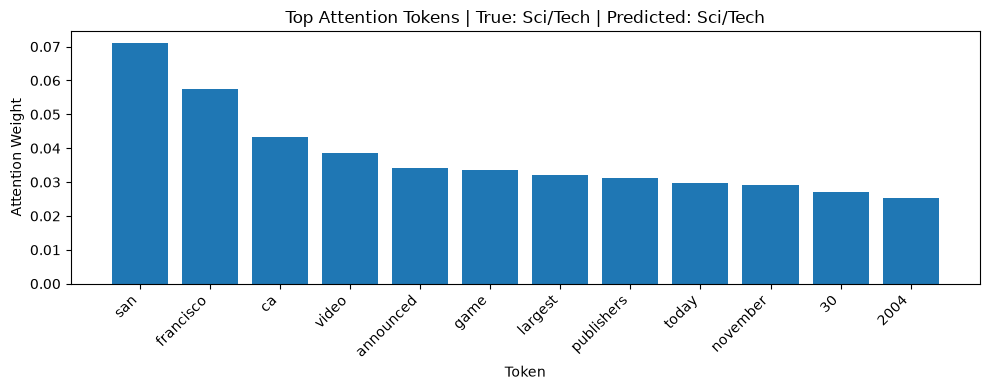

True Label     : Sports
Predicted Label: Sports
Article: DANIEL VETTORI spun New Zealand to the brink of a crushing victory over Bangladesh in the second and final Test at the MA Aziz Stadium in Chittagong today.


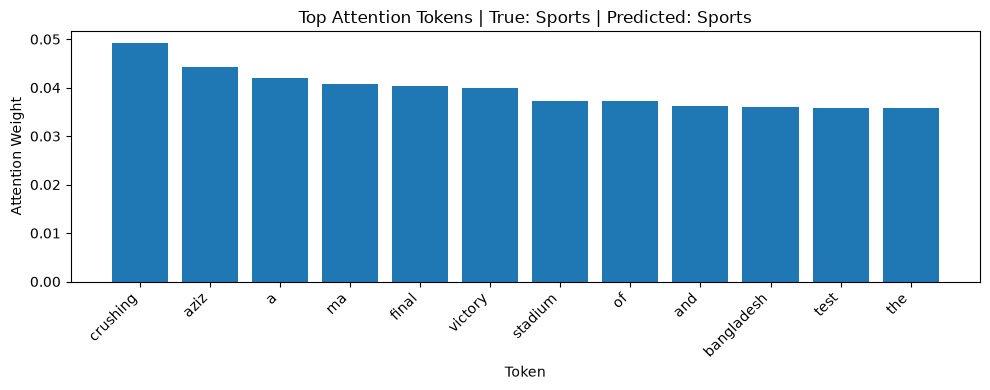

In [12]:
def get_tokens_and_attention(text):
    token_ids = vectorizer(tf.constant([text]))
    token_array = token_ids.numpy()[0]

    vocabulary = np.array(vectorizer.get_vocabulary())
    tokens = [
        vocabulary[token_id]
        for token_id in token_array
        if token_id != 0
    ]

    _, weights = inference_model.predict(
        tf.constant([text]),
        verbose=0
    )

    weights = weights[0][:len(tokens)]
    return tokens, weights

sample_indices = [0, 1, 2, 3]

for idx in sample_indices:
    tokens, weights = get_tokens_and_attention(test_texts[idx])

    top_k = min(12, len(tokens))
    top_indices = np.argsort(weights)[-top_k:][::-1]

    print("=" * 100)
    print("True Label     :", class_names[test_labels[idx]])
    print("Predicted Label:", class_names[predictions[idx]])
    print("Article:", test_texts[idx][:500])

    plt.figure(figsize=(10, 4))
    plt.bar(
        [tokens[i] for i in top_indices],
        [weights[i] for i in top_indices]
    )
    plt.xlabel("Token")
    plt.ylabel("Attention Weight")
    plt.title(
        f"Top Attention Tokens | True: {class_names[test_labels[idx]]} | "
        f"Predicted: {class_names[predictions[idx]]}"
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 13. Key Findings

- The BiLSTM with attention achieved a **test accuracy of 90.93%** and a **weighted F1-score of 0.9091** on the AG News test set.
- The best validation performance occurred at **Epoch 2**, with a validation accuracy of **90.75%** and validation loss of **0.2772**. Training accuracy continued to increase after this point while validation performance declined, indicating clear overfitting.
- Performance was strongest for the **Sports** category, which achieved an F1-score of **0.9621** and recall of **0.9816**.
- The **Business** category was the most difficult class, with an F1-score of **0.8764**, reflecting greater ambiguity between business and related news topics.
- The model produced correct predictions for the selected attention visualizations, while the attention weights identified specific tokens within the articles that contributed strongly to the classification decision.
- The results demonstrate that the attention mechanism can provide a more focused representation of a document by assigning different weights to different positions in the sequence.

# 14. Conclusion

The BiLSTM with an additive attention mechanism achieved strong performance on multi-class AG News topic classification, reaching **90.93% test accuracy**. The model generalized well at the beginning of training, although the increasing gap between training and validation performance after the second epoch indicates overfitting.

The attention mechanism provided an additional view into the model's decision process by assigning different weights to tokens within each article. This makes the model's sequence representation more selective than treating every encoded position equally and provides a useful basis for analysing which parts of a news article contribute most to its predicted topic.